# 视网膜疾病分类演示 Notebook

欢迎来到视网膜疾病分类模型的演示。这个 Notebook 将引导您完成以下流程：

1.  **数据集探索**: 加载我们采样后的数据集，并可视化不同类别的样本图像。
2.  **模型加载**: 自动加载我们使用 SqueezeNet 训练好的最新分类模型。
3.  **单图预测与可视化**: 对一张随机抽取的图像进行预测，并用条形图直观展示模型的预测置信度。
4.  **模型整体性能评估**: 在整个验证集上进行预测，并使用**混淆矩阵 (Confusion Matrix)** 来可视化模型的整体性能，直观地看出模型容易混淆哪些类别。

---

### 前置步骤: 导入必要的库和模块
首先导入所有需要的库，包括我们为分类任务编写的 `utils` 模块。

In [7]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models
from PIL import Image
import numpy as np
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 导入我们自己的模块
# 切换工作目录以确保模块可以被找到
# 注意：请根据您的项目结构调整此路径
try:
    # 假设 notebook 在 classification 文件夹内
    from utils import get_data_transforms, get_class_names
except ImportError:
    # 如果直接在 retinal 目录下运行，可能需要调整路径
    print("无法直接导入模块，请确保 Notebook 的工作目录正确。")
    # 或者手动添加路径
    # sys.path.append('./classification')
    # from utils import get_data_transforms, get_class_names


# --- Matplotlib 中文显示设置 ---
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False    # 解决保存图像是负号'-'显示为方块的问题

print("所有库和模块已成功导入！")

所有库和模块已成功导入！


### 步骤 1: 配置、加载数据并进行探索

加载之前采样的小型数据集，并随机展示几个类别的图像，以了解数据的大致情况。


数据集加载成功！共找到 39 个类别。
类别列表: ['0.0.Normal', '0.1.Tessellated fundus', '0.2.Large optic cup', '0.3.DR1', '1.0.DR2', '1.1.DR3', '10.0.Possible glaucoma', '10.1.Optic atrophy', '11.Severe hypertensive retinopathy', '12.Disc swelling and elevation', '13.Dragged Disc', '14.Congenital disc abnormality', '15.0.Retinitis pigmentosa', '15.1.Bietti crystalline dystrophy', '16.Peripheral retinal degeneration and break', '17.Myelinated nerve fiber', '18.Vitreous particles', '19.Fundus neoplasm', '2.0.BRVO', '2.1.CRVO', '20.Massive hard exudates', '21.Yellow-white spots-flecks', '22.Cotton-wool spots', '23.Vessel tortuosity', '24.Chorioretinal atrophy-coloboma', '25.Preretinal hemorrhage', '26.Fibrosis', '27.Laser Spots', '28.Silicon oil in eye', '29.0.Blur fundus without PDR', '29.1.Blur fundus with suspected PDR', '3.RAO', '4.Rhegmatogenous RD', '5.0.CSCR', '5.1.VKH disease', '6.Maculopathy', '7.ERM', '8.MH', '9.Pathological myopia']


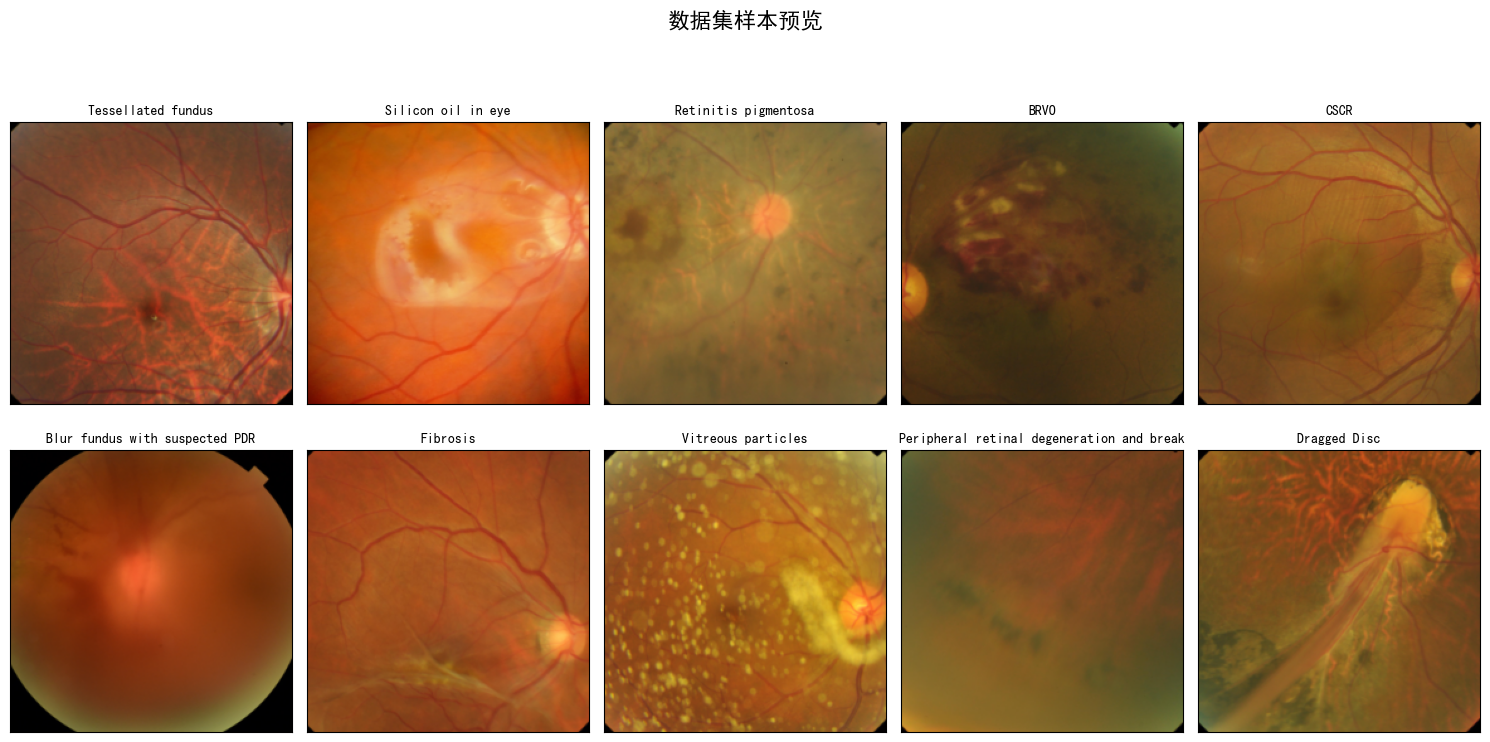

In [11]:
# --- 配置 ---
DATASET_DIR = r'classification\datasets\sampled_images'
OUTPUTS_DIR = r'classification\outputs'

# --- 加载数据 ---
# 使用 ImageFolder 加载数据集
data_transforms = get_data_transforms()
full_dataset = datasets.ImageFolder(DATASET_DIR, transform=data_transforms['val']) # 使用验证集变换进行可视化
class_names = full_dataset.classes
print(f"数据集加载成功！共找到 {len(class_names)} 个类别。")
print("类别列表:", class_names)

# --- 可视化数据集样本 ---
def show_dataset_samples(dataset, num_samples=10):
    fig = plt.figure(figsize=(15, 8))
    plt.suptitle("数据集样本预览", fontsize=16)
    
    indices = random.sample(range(len(dataset)), num_samples)
    
    for i, idx in enumerate(indices):
        image, label_idx = dataset[idx]
        ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
        
        # 反标准化图像以供显示
        image = image.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)
        
        ax.imshow(image)
        ax.set_title(class_names[label_idx].split('.')[-1], fontsize=10) # 显示更简洁的类名
        
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

show_dataset_samples(full_dataset)

### 步骤 2: 加载训练好的模型

与分割任务类似，我们自动查找并加载最新的分类模型。

In [12]:
# --- 自动查找最新模型 ---
def get_latest_model_path(output_dir):
    try:
        subdirs = [d for d in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir, d))]
        if not subdirs: return None, None
        latest_dir = sorted(subdirs)[-1]
        model_path = os.path.join(output_dir, latest_dir, 'best_model.pth')
        class_names_path = os.path.join(output_dir, latest_dir, 'class_names.json')
        return model_path if os.path.exists(model_path) else None, class_names_path
    except FileNotFoundError:
        return None, None

MODEL_PATH, CLASS_NAMES_PATH = get_latest_model_path(OUTPUTS_DIR)
if not MODEL_PATH:
    raise FileNotFoundError(f"在 '{OUTPUTS_DIR}' 中找不到任何模型，请先运行 train_model.py")

print(f"将使用的模型: {MODEL_PATH}")

# --- 加载类别名称 ---
with open(CLASS_NAMES_PATH, 'r') as f:
    loaded_class_names = json.load(f)
num_classes = len(loaded_class_names)

# --- 加载模型 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.squeezenet1_1(pretrained=False)
model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1), stride=(1,1))
model.num_classes = num_classes
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print(f"模型已成功加载到设备: {device}")

将使用的模型: D:\Zephyr\Documents\SVNResources\retinal\classification\outputs\20260307-215950\best_model.pth
模型已成功加载到设备: cpu


D:\software\Anaconda\envs\retinal\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\software\Anaconda\envs\retinal\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


### 步骤 3: 单张图片预测与置信度可视化

这是最直观的演示部分。我们随机选择一张图片，让模型进行预测，然后用条形图清晰地展示模型对最可能的几个类别的判断依据（置信度概率）。

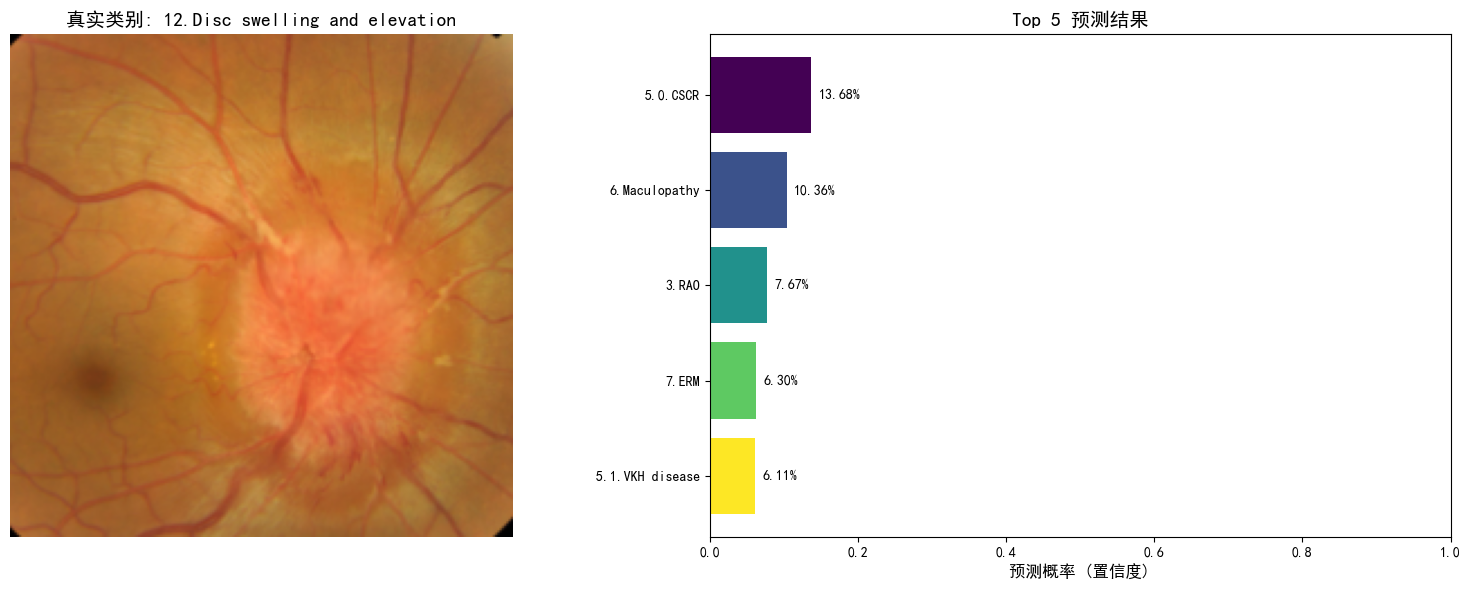

In [13]:

sample_idx = random.randint(0, len(full_dataset) - 1)
image, true_label_idx = full_dataset[sample_idx]
true_label_name = loaded_class_names[true_label_idx]

# --- 模型预测 ---
input_tensor = image.unsqueeze(0).to(device)
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_indices = torch.topk(probabilities, 5)

# --- 可视化预测结果 ---
# 反标准化图像
image_to_show = image.numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image_to_show = std * image_to_show + mean
image_to_show = np.clip(image_to_show, 0, 1)

# 准备条形图数据
top5_labels = [loaded_class_names[i] for i in top5_indices.cpu().numpy()]
top5_probs_values = top5_prob.cpu().numpy()

# 创建并排图
fig, (ax1, ax2) = plt.subplots(figsize=(16, 6), ncols=2)

# 显示图片
ax1.imshow(image_to_show)
ax1.set_title(f"真实类别: {true_label_name}", fontsize=14)
ax1.axis('off')

# 显示条形图
bars = ax2.barh(top5_labels, top5_probs_values, color=plt.cm.viridis(np.linspace(0, 1, 5)))
ax2.set_xlabel('预测概率 (置信度)', fontsize=12)
ax2.set_title('Top 5 预测结果', fontsize=14)
ax2.invert_yaxis() # 将概率最高的放在最上面
ax2.set_xlim(0, 1.0)
# 在条形图上显示数值
for bar in bars:
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.2%}', va='center')

plt.tight_layout()
plt.show()

### 步骤 4: 模型整体性能评估 - 混淆矩阵

为了更全面地了解模型的性能，而不仅仅是单张图片的表现，我们将在整个验证集上运行预测，并生成一个**混淆矩阵**。

**混淆矩阵能告诉我们**：
- **对角线**: 模型正确分类了多少样本。
- **非对角线**: 模型将一个类别错误地预测成了另一个类别（例如，将 "DR1" 错误地识别为 "DR2"）。

这对于分析模型的弱点非常有帮助。

C:\Users\Zephyr\AppData\Local\Temp\ipykernel_38464\82318383.py:29: RuntimeWarning: invalid value encountered in divide
  cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


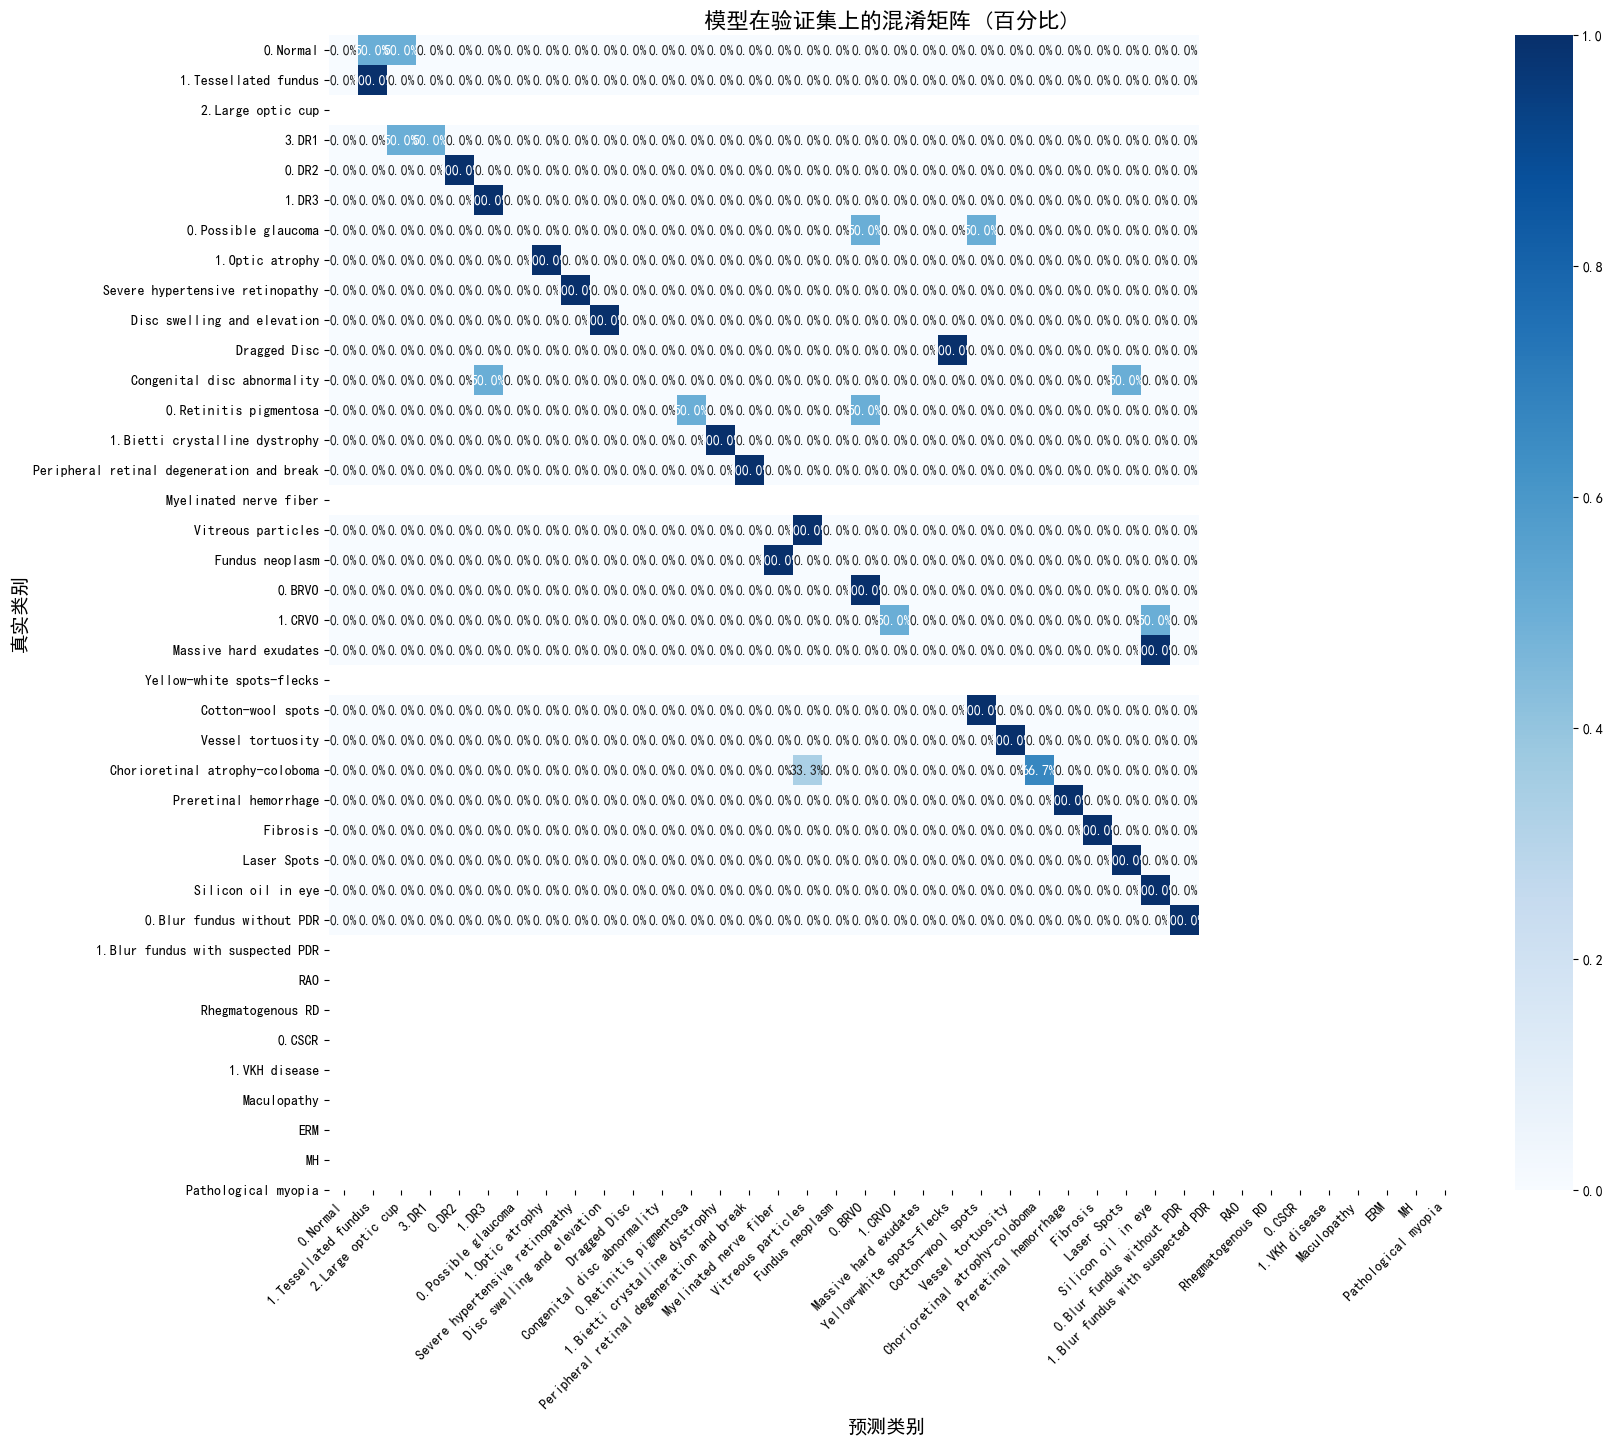

In [14]:
# %%
# --- 准备验证集数据加载器 ---
# 我们需要重新加载完整数据集，并进行与训练时相同的划分
train_val_dataset = datasets.ImageFolder(DATASET_DIR, transform=data_transforms['val'])
train_size = int(0.67 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
_, val_dataset = random_split(train_val_dataset, [train_size, val_size])

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# --- 在验证集上收集所有预测结果 ---
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- 计算并绘制混淆矩阵 ---
cm = confusion_matrix(all_labels, all_preds)
# 为了更好的可视化，我们可以将原始数量转换为百分比
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(18, 15))
# 使用更简洁的标签名
short_class_names = [name.split('.', 1)[-1] for name in loaded_class_names]
sns.heatmap(cm_percent, annot=True, fmt='.1%', cmap='Blues', 
            xticklabels=short_class_names, yticklabels=short_class_names)
plt.title('模型在验证集上的混淆矩阵 (百分比)', fontsize=16)
plt.ylabel('真实类别', fontsize=14)
plt.xlabel('预测类别', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
